# Calculation of urine concentrations expressed per creatinine

This piece of code shows how to compute urine concentrations expressed per gram creatinine based on the simulation results.

## Setup and run model

In [12]:
import tellurium as te
import matplotlib.pyplot as plt

fn_ant = '../model/PBK_Cd.ant'

# Exposure scenario
input_id = 'AGut'
daily_intake = 1 # 1 ug/kg bw/d
days_of_exposure = 80 * 365
days_after_exposure = 10 * 365
num_days = days_of_exposure + days_after_exposure
evaluation_frequency = 10 # evals per unit of time

# Load the PBPK model from the SBML file
rr_model = te.loada(fn_ant)

# Make sure A_gut is not constant and does not have boundary conditions
rr_model.setInitAmount(input_id, 0)
rr_model.setConstant(input_id, False)
rr_model.setBoundary(input_id, False)

# Create a repeating daily oral dosing
eid = f"oral_daily_exposure"
rr_model.addEvent(eid, False, f"time % 1 == 0 && time < {days_of_exposure}", False)
rr_model.addEventAssignment(eid, input_id, f"{input_id} + {daily_intake} * BW", False)
rr_model.regenerateModel(True, True)

# Simulate the PBPK model (include BW, age, urine volume, and other variables in output)
plot_params = rr_model.timeCourseSelections + ['BW', 'Age', 'Urine', 'VCreat', 'Cd_Urine']
results = rr_model.simulate(0, num_days, evaluation_frequency * num_days + 1, plot_params)

## Plot results

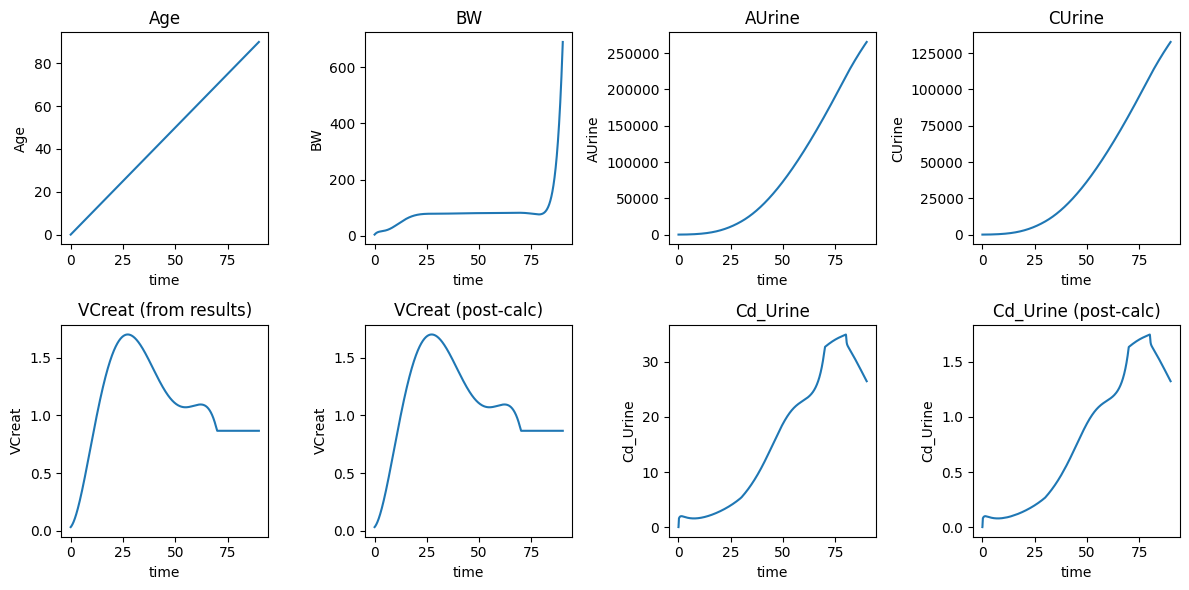

In [ ]:
def calc_creat(age):
    if (age < 70):
        return 0.032 \
            + 2.098e-02*age \
            + 9.104e-03*(age**2) \
            - 4.550e-04*(age**3) \
            + 7.578e-06*(age**4) \
            - 4.232e-08*(age**5)
    else:
        return 0.032 \
            + 2.098e-02*70 \
            + 9.104e-03*(70**2) \
            - 4.550e-04*(70**3) \
            + 7.578e-06*(70**4) \
            - 4.232e-08*(70**5)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for ax in axes:
    ax.set(xlabel='time') 

years = results['time'] / 365
axes[0].plot(years, results['Age'])
axes[0].set(ylabel=f"Age", title='Age')

axes[1].plot(years, results['BW'])
axes[1].set(ylabel=f"BW", title='BW')

axes[2].plot(years, results['[AUrine]'])
axes[2].set(ylabel=f"AUrine", title='AUrine')

urine_concentrations = [a / b for a,b in zip(results['[AUrine]'], results['Urine'])]
axes[3].plot(years, urine_concentrations)
axes[3].set(ylabel=f"CUrine", title='CUrine')

axes[4].plot(years, results['VCreat'])
axes[4].set(ylabel=f"VCreat", title='VCreat (from results)')

creat_computed = [calc_creat(age) for age in results['Age']]
axes[5].plot(years, creat_computed)
axes[5].set(ylabel=f"VCreat", title='VCreat (post-calc)')

axes[6].plot(years, results['Cd_Urine'])
axes[6].set(ylabel=f"Cd_Urine", title='Cd_Urine')

## Get daily excreted amounts from the cumulative urine amount
differences = [0]
a_urine = results['[AUrine]']
differences.extend(a_urine[i] - a_urine[i-1] for i in range(1, len(a_urine)))

urine_creat = [a / b for a,b in zip(differences, creat_computed)]
axes[7].plot(years, urine_creat)
axes[7].set(ylabel=f"Cd_Urine", title='Cd_Urine (post-calc)')

fig.tight_layout()
